# This notebook: 
## 1. extracts satellite Global Monthly Precipitation (NASA GPM IMERG) data from ERDDAP using specified coordinates and time windows. Data comes from this server: https://erddap.marine.usf.edu/erddap/info/index.html?
## 2. maps precip for a selected time
## 3. identifies the month at which the lowest and highest precip value are reached over a yearly cycle at the pixel level
## 4. maps the month value per pixel for the lowest and highest precip level

### Download data

In [1]:
import xarray as xr
import numpy as np
import requests
import os

# 1. Define Coordinates and Time (Consistent with Chl-a/nFLH domains)
n_lat, s_lat = 31, 21
e_lon, w_lon = -79.5, -90
start_time = '1998-01-00T00:00:00Z'
end_time = '2025-09-00T00:00:00Z' # Constrained to late 2024 to ensure finalized record availability

# 2. Construct the ERDDAP URL for GPM IMERG
# Using standard NOAA AOML / CoastWatch ERDDAP IMERG configurations
base_url = "https://erddap.marine.usf.edu/erddap/griddap/IMERG_monthly_global_precip.nc"
variable_name = "precipitation" # Standard IMERG calibrated precipitation variable

query = f"?{variable_name}[({start_time}):1:({end_time})][({n_lat}):1:({s_lat})][({w_lon}):1:({e_lon})]"
full_url = base_url + query

filename = 'gpm_imerg_precipitation.nc'
parent_filename = os.path.join('..', filename)

# 3. Handle File Path Checking and Stream Download
if os.path.exists(filename):
    file_path = filename
    print(f"✅ Found local file {filename} in current directory. Skipping download.")
elif os.path.exists(parent_filename):
    file_path = parent_filename
    print(f"✅ Found local file one directory up: {parent_filename}. Skipping download.")
else:
    file_path = filename
    print(f"📡 Downloading NASA GPM IMERG data from: {full_url}")
    print("This may take several minutes depending on network speeds...")
    
    try:
        # Use stream=True to download safely chunk-by-chunk into RAM
        with requests.get(full_url, stream=True, timeout=1800) as r:
            r.raise_for_status()  # Catch ERDDAP errors immediately
            with open(file_path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
        print("✅ Download complete.")
    except Exception as e:
        print(f"❌ Failed to download data. Error: {e}")

# 4. Load and Inspect Dataset
if os.path.exists(file_path):
    ds = xr.open_dataset(file_path)

    # Extract coordinates and primary data arrays
    lat = ds.latitude.values
    lon = ds.longitude.values
    precipitation = ds[variable_name].values
    time = ds.time.values

    # Python equivalent of [lat1, lon1] = meshgrid(lat, lon)
    lon1, lat1 = np.meshgrid(lon, lat)

    # View the loaded dataset structure
    print("\n🚀 Dataset successfully loaded into xarray:")
    print(ds)
else:
    print(f"❌ Critical Error: '{file_path}' does not exist on disk. Check download steps.")

✅ Found local file gpm_imerg_precipitation.nc in current directory. Skipping download.

🚀 Dataset successfully loaded into xarray:
<xarray.Dataset> Size: 29MB
Dimensions:        (time: 333, latitude: 101, longitude: 106)
Coordinates:
  * time           (time) datetime64[ns] 3kB 1998-01-01 ... 2025-09-01
  * latitude       (latitude) float32 404B 31.05 30.95 30.85 ... 21.15 21.05
  * longitude      (longitude) float32 424B -90.05 -89.95 ... -79.65 -79.55
Data variables:
    precipitation  (time, latitude, longitude) float64 29MB 352.7 ... 253.4
Attributes: (12/42)
    cdm_data_type:              Grid
    Composite_date:             20250901
    contact:                    Dan Otis - dotis@usf.edu
    Conventions:                COARDS, CF-1.6, ACDD-1.3
    CreationDate:               02/09/2026 20:48:16
    creator_email:              dotis@usf.edu
    ...                         ...
    summary:                    NASA GPM IMERG Global Monthly Precipitation
    time_coverage_end:      

### Mask Ocean Pixels Using Bathymetry (Land-Only Precipitation)

Found local file topo_data.nc. Skipping download.
✅ Bathymetry dataset successfully loaded into 'topo_ds'.
Interpolating bathymetry onto the precipitation grid...
✅ Ocean masking complete. 'precip_land' added to the dataset.


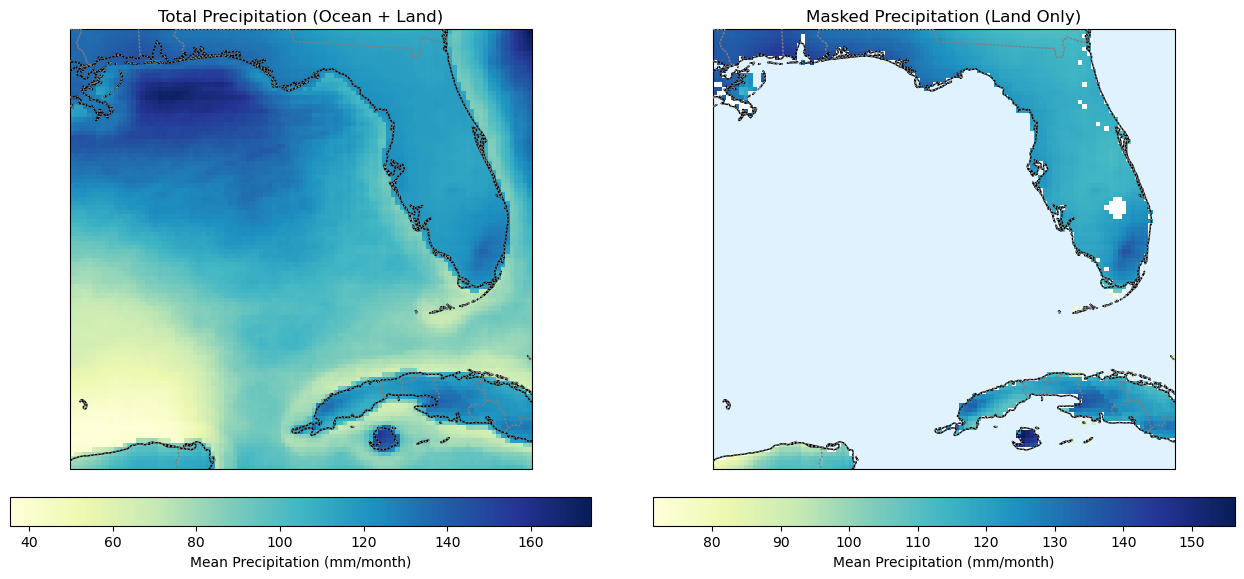

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import requests

# --- 1. Download Bathymetry Data (ETOPO) ---
topo_filename = 'topo_data.nc'
parent_topo_filename = os.path.join('..', topo_filename)

topo_url = (
    f"https://coastwatch.pfeg.noaa.gov/erddap/griddap/etopo180.nc?altitude"
    f"[({min(s_lat, n_lat)}):1:({max(s_lat, n_lat)})]"
    f"[({min(w_lon, e_lon)}):1:({max(w_lon, e_lon)})]"
)

# Determine path and download if missing
if os.path.exists(topo_filename):
    file_to_load = topo_filename
    print(f"Found local file {topo_filename}. Skipping download.")
elif os.path.exists(parent_topo_filename):
    file_to_load = parent_topo_filename
    print(f"Found local file one directory up: {parent_topo_filename}. Skipping download.")
else:
    file_to_load = topo_filename
    print(f"Attempting to download bathymetry from: {topo_url}")
    try:
        r = requests.get(topo_url, timeout=120)
        if r.status_code == 200:
            with open(topo_filename, 'wb') as f:
                f.write(r.content)
            print("Bathymetry download complete.")
        else:
            print(f"Download failed with status {r.status_code}.")
            file_to_load = None
    except Exception as e:
        print(f"Error occurred during download: {e}")
        file_to_load = None

# --- Load topo_ds into memory ---
if file_to_load and os.path.exists(file_to_load):
    try:
        topo_ds = xr.open_dataset(file_to_load)
        print("✅ Bathymetry dataset successfully loaded into 'topo_ds'.")
    except Exception as e:
        print(f"❌ Failed to open bathymetry file: {e}")
        topo_ds = None
else:
    topo_ds = None


# --- 2. Mask Ocean Pixels Using Bathymetry (Land-Only Precipitation) ---
if 'ds' in locals() and topo_ds is not None:
    
    # Interpolate Bathymetry to GPM IMERG Grid
    print("Interpolating bathymetry onto the precipitation grid...")
    topo_interp = topo_ds['altitude'].interp(
        latitude=ds.latitude, 
        longitude=ds.longitude, 
        method='linear'
    )
    
    # Create the Land Mask (True where altitude >= 0)
    land_mask = topo_interp >= 0
    
    # Apply Mask to the Precipitation Data Array
    precip_variable = "precipitation"  # From Cell 1
    ds['precip_land'] = ds[precip_variable].where(land_mask)
    
    # Calculate Climatological Land Precipitation (Time Average)
    mean_land_precip = ds['precip_land'].mean(dim='time', keep_attrs=True)
    
    print("✅ Ocean masking complete. 'precip_land' added to the dataset.")
    
    # --- VISUALIZATION ---
    fig = plt.figure(figsize=(14, 6))
    
    # Subplot 1: Original Precipitation (Land + Ocean)
    ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
    ax1.set_extent([-90, -79.5, 21, 31], crs=ccrs.PlateCarree())
    ax1.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black', zorder=3)
    ax1.add_feature(cfeature.STATES, linestyle=':', edgecolor='gray', zorder=3)
    
    im1 = ax1.pcolormesh(ds.longitude, ds.latitude, ds[precip_variable].mean(dim='time'),
                         cmap='YlGnBu', transform=ccrs.PlateCarree())
    plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.8,
                 label='Mean Precipitation (mm/month)')
    ax1.set_title('Total Precipitation (Ocean + Land)')
    
    # Subplot 2: Masked Precipitation (Land Only)
    ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
    ax2.set_extent([-90, -79.5, 21, 31], crs=ccrs.PlateCarree())
    ax2.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black', zorder=3)
    ax2.add_feature(cfeature.OCEAN, facecolor='#e0f2fe', zorder=1)
    ax2.add_feature(cfeature.STATES, linestyle=':', edgecolor='gray', zorder=3)
    
    im2 = ax2.pcolormesh(ds.longitude, ds.latitude, mean_land_precip,
                         cmap='YlGnBu', transform=ccrs.PlateCarree(), zorder=2)
    plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.8,
                 label='Mean Precipitation (mm/month)')
    ax2.set_title('Masked Precipitation (Land Only)')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ Error: Both GPM dataset ('ds') and bathymetry ('topo_ds') must be loaded in memory to run this cell.")

### Map precip for a selected month and year

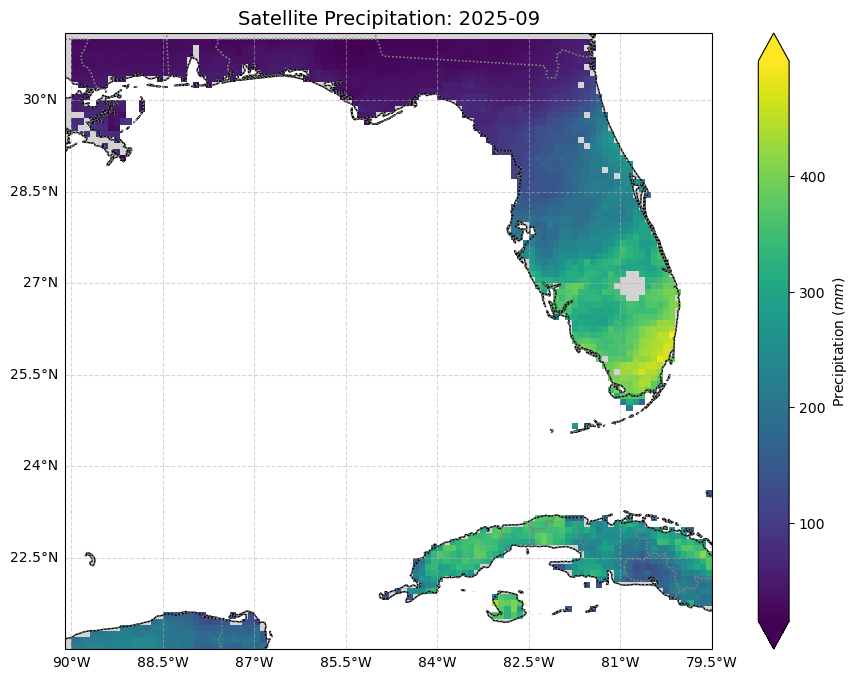

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm

# 1. Select the specific time slice
# Example: Select January 2015. 
# You can use a string 'YYYY-MM' with xarray's .sel() method
target_time = '2025-09'
data_slice = ds.precip_land.sel(time=target_time, method='nearest')

# 2. Setup the map projection
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# 3. Plot the data
im = ax.pcolormesh(ds.longitude, ds.latitude, data_slice,
                   transform=ccrs.PlateCarree(),
                   cmap='viridis')

# 4. Add geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='gray')
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# 5. Add gridlines and labels
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# 6. Add Colorbar and Labels
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.05, extend='both')
cbar.set_label('Precipitation ($mm$)')

plt.title(f'Satellite Precipitation: {target_time}', fontsize=14)
# plt.savefig()
plt.show()

### To find the month when precipitation peaks for every pixel, we need to perform these steps:
###  1. Group the data by month.
###  2. Calculate the climatological mean (the "average" year) to smooth out episodic events (like hurricanes).
###  3. Find the index (month) where the maximum value occurs for every latitude/longitude point.

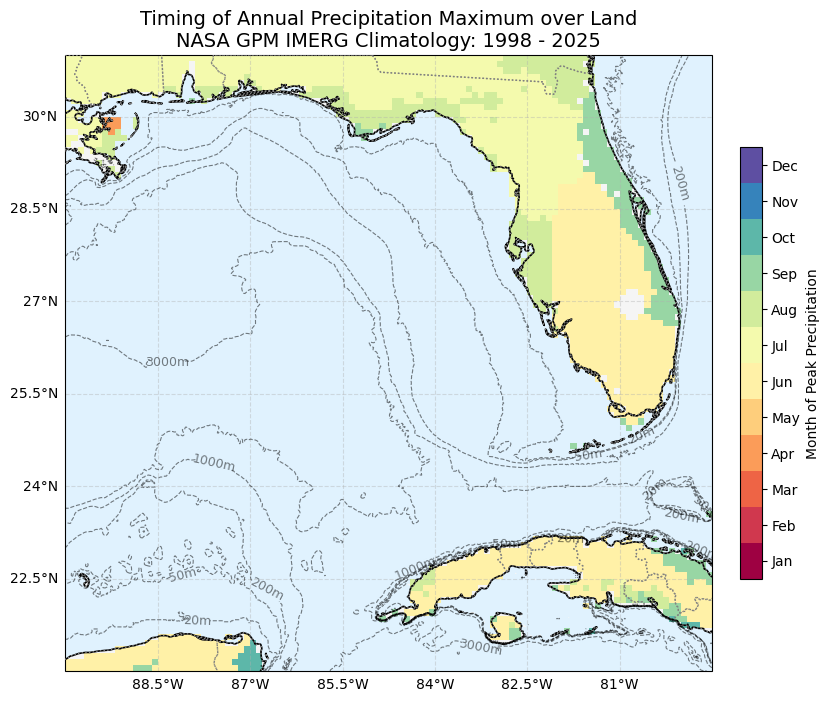

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas
import xarray as xr
import numpy as np
import requests
import os

# --- 1. Calculate the Precipitation Peak Month ---
# 1 & 2. Group data by month and calculate the climatological mean over land
climatology = ds.precip_land.groupby('time.month').mean(dim='time')

# 3. Find the index (month 1-12) where the maximum value occurs for every point
peak_month = climatology.idxmax(dim='month').load()
trough_month = climatology.idxmin(dim='month').load()

# --- 2. Load Data and Setup Plot ---
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
# Extent matching the precipitation dataset domain
ax.set_extent([-90, -79.5, 21, 31], crs=ccrs.PlateCarree())
cmap = plt.get_cmap('Spectral', 12)

# --- 3. Plot Land Precipitation Peak Month ---
# Ocean pixels are masked out (NaN) and will render as transparent automatically
im = ax.pcolormesh(ds.longitude, ds.latitude, peak_month,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap, vmin=0.5, vmax=12.5, zorder=2)

# --- 4. Add Bathymetry Contours (If data is available) ---
if file_to_load and os.path.exists(file_to_load):
    topo_ds = xr.open_dataset(file_to_load)
    # Focus on coastal shelf depth lines relevant to the Gulf/Florida region
    levels = [-3000, -1000, -200, -50, -20]
    
    contours = ax.contour(topo_ds.longitude, topo_ds.latitude, topo_ds.altitude, 
                           levels=levels, colors='black', 
                           linewidths=0.8, alpha=0.5, 
                           transform=ccrs.PlateCarree(), zorder=4)

    plt.clabel(contours, inline=True, fontsize=9, fmt={lev: f'{int(abs(lev))}m' for lev in levels})

# --- 5. Add Geographic Features ---
# Since data is over land, fill the ocean with a solid color so the land pixels stand out
ax.add_feature(cfeature.OCEAN, facecolor='#e0f2fe', zorder=1)
ax.add_feature(cfeature.LAND, facecolor='#f5f5f5', zorder=1) # Background for land areas without rain
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=3)
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='gray', zorder=3)

# --- 6. Gridlines ---
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4, zorder=5)
gl.top_labels = False
gl.right_labels = False

# --- 7. Formatting ---
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, ticks=range(1, 13), shrink=0.7)
cbar.set_ticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
cbar.set_label('Month of Peak Precipitation')

# Extract years dynamically from dataset time index for title accuracy
start_year = pandas.to_datetime(ds.time.values[0]).year if 'pandas' in locals() else 2003
end_year = pandas.to_datetime(ds.time.values[-1]).year if 'pandas' in locals() else 2024

plt.title(f'Timing of Annual Precipitation Maximum over Land\nNASA GPM IMERG Climatology: {start_year} - {end_year}', fontsize=14)
plt.show()

### Time Series of Precipitation with SD Envelope

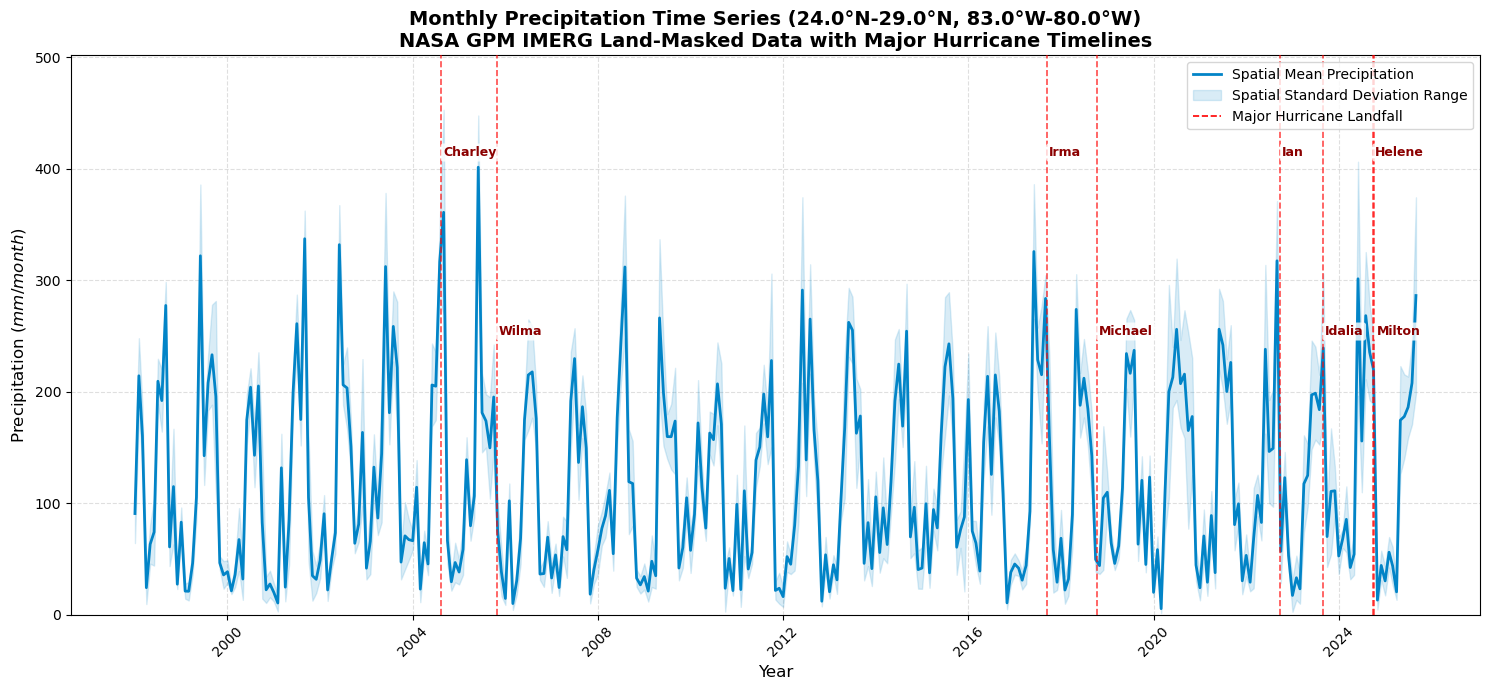

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# --- 1. SETTINGS & PARAMETERS ---
lat_min, lat_max = 24.0, 29.0
lon_min, lon_max = -83.0, -80.0

start_date = '1998-01-01'
end_date = '2025-12-31'

# --- 2. SPATIAL & TEMPORAL SUBSETTING ---
lat_name = 'latitude' if 'latitude' in ds.coords else 'lat'
lon_name = 'longitude' if 'longitude' in ds.coords else 'lon'

# Dynamic coordinate orientation check
lat_coords = ds[lat_name].values
lat_slice = slice(lat_max, lat_min) if lat_coords[0] > lat_coords[-1] else slice(lat_min, lat_max)

lon_coords = ds[lon_name].values
lon_slice = slice(lon_max, lon_min) if lon_coords[0] > lon_coords[-1] else slice(lon_min, lon_max)

ds_subset = ds['precip_land'].sel(
    {
        lat_name: lat_slice,
        lon_name: lon_slice,
        'time': slice(start_date, end_date)
    }
)

# --- 3. CALCULATE SPATIAL MEAN AND STANDARD DEVIATION ---
spatial_mean = ds_subset.mean(dim=[lat_name, lon_name], skipna=True).load()
spatial_std = ds_subset.std(dim=[lat_name, lon_name], skipna=True).load()
time_axis = pd.to_datetime(spatial_mean.time.values)

# --- 4. DEFINE MAJOR FLORIDA HURRICANES (2000 - 2025) ---
# Landfall dates of notable storms within the region
hurricanes = [
    {"name": "Charley", "date": "2004-08-13"},
    {"name": "Wilma", "date": "2005-10-24"},
    {"name": "Irma", "date": "2017-09-10"},
    {"name": "Michael", "date": "2018-10-10"},
    {"name": "Ian", "date": "2022-09-28"},
    {"name": "Idalia", "date": "2023-08-30"},
    {"name": "Helene", "date": "2024-09-26"},
    {"name": "Milton", "date": "2024-10-09"}
]

# --- 5. RENDER TIME SERIES PLOT ---
plt.figure(figsize=(15, 7))

# Plot the mean precipitation line
plt.plot(time_axis, spatial_mean, color='#0284c7', linewidth=2, label='Spatial Mean Precipitation', zorder=3)

# Plot the Standard Deviation envelope
lower_bound = np.maximum(spatial_mean - spatial_std, 0)
upper_bound = spatial_mean + spatial_std
plt.fill_between(
    time_axis, 
    lower_bound, 
    upper_bound, 
    color='#0284c7', 
    alpha=0.15, 
    label='Spatial Standard Deviation Range',
    zorder=2
)

# --- 6. ADD HURRICANE ANNOTATIONS ---
# Get current y-axis maximum to dynamically place text labels
max_y_value = float(spatial_mean.max().values) if hasattr(spatial_mean.max(), 'values') else float(spatial_mean.max())
y_limits = [0, max_y_value * 1.25] # Set limits slightly above the peak for visual breathing room

for i, storm in enumerate(hurricanes):
    storm_date = pd.to_datetime(storm['date'])
    
    # Only draw if the storm falls within our plotted time window
    if time_axis.min() <= storm_date <= time_axis.max():
        # Draw the red dashed vertical line
        plt.axvline(x=storm_date, color='red', linestyle='--', linewidth=1.2, alpha=0.7, zorder=4)
        
        # Alternate height positions for the labels to prevent overlapping
        # E.g., placing some labels near the top (82%) and others mid-way (50%) of the plot limit
        y_pos = y_limits[1] * (0.82 if i % 2 == 0 else 0.50)
        
        # Add the text annotation slightly offset to the right (+ 15 days) of the vertical line
        plt.text(
            storm_date + pd.Timedelta(days=15), 
            y_pos, 
            storm['name'], 
            color='darkred', 
            fontsize=9, 
            fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'),
            zorder=5
        )

# --- 7. FORMATTING ---
plt.ylim(y_limits)
plt.title(
    f'Monthly Precipitation Time Series ({lat_min}°N-{lat_max}°N, {abs(lon_min)}°W-{abs(lon_max)}°W)\n'
    f'NASA GPM IMERG Land-Masked Data with Major Hurricane Timelines', 
    fontsize=14, 
    fontweight='bold'
)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Precipitation ($mm/month$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4, zorder=1)

# Combined legend with custom hurricane entry
handles, labels = plt.gca().get_legend_handles_labels()
from matplotlib.lines import Line2D
hurricane_line = Line2D([0], [0], color='red', linestyle='--', linewidth=1.2, label='Major Hurricane Landfall')
handles.append(hurricane_line)

plt.legend(handles=handles, loc='upper right', frameon=True, fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Fetch Catchment Polygons & Calculate Basin-Specific Precipitation

📡 Fetching catchment polygons from USGS NLDI API...
✅ Retrieved polygon for Caloosahatchee River (Area: 2259.2 km²)
✅ Retrieved polygon for Manatee River (Area: 182.2 km²)
✅ Retrieved polygon for Peace River (Area: 3434.4 km²)
✅ Retrieved polygon for Myakka River (Area: 599.2 km²)
✅ Retrieved polygon for Hillsborough River (Area: 1565.7 km²)
✅ Retrieved polygon for Shark River (Area: 8488.9 km²)

🌧️ Slicing precipitation data inside catchment boundaries...
📊 Extracted precipitation time series for Caloosahatchee River


ERROR 1: PROJ: internal_proj_create_from_database: /home/enrique.montes@CNS.local/miniconda3/envs/seas_env/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 5 whereas a number >= 6 is expected. It comes from another PROJ installation.


📊 Extracted precipitation time series for Manatee River
📊 Extracted precipitation time series for Peace River
📊 Extracted precipitation time series for Myakka River
📊 Extracted precipitation time series for Hillsborough River
📊 Extracted precipitation time series for Shark River


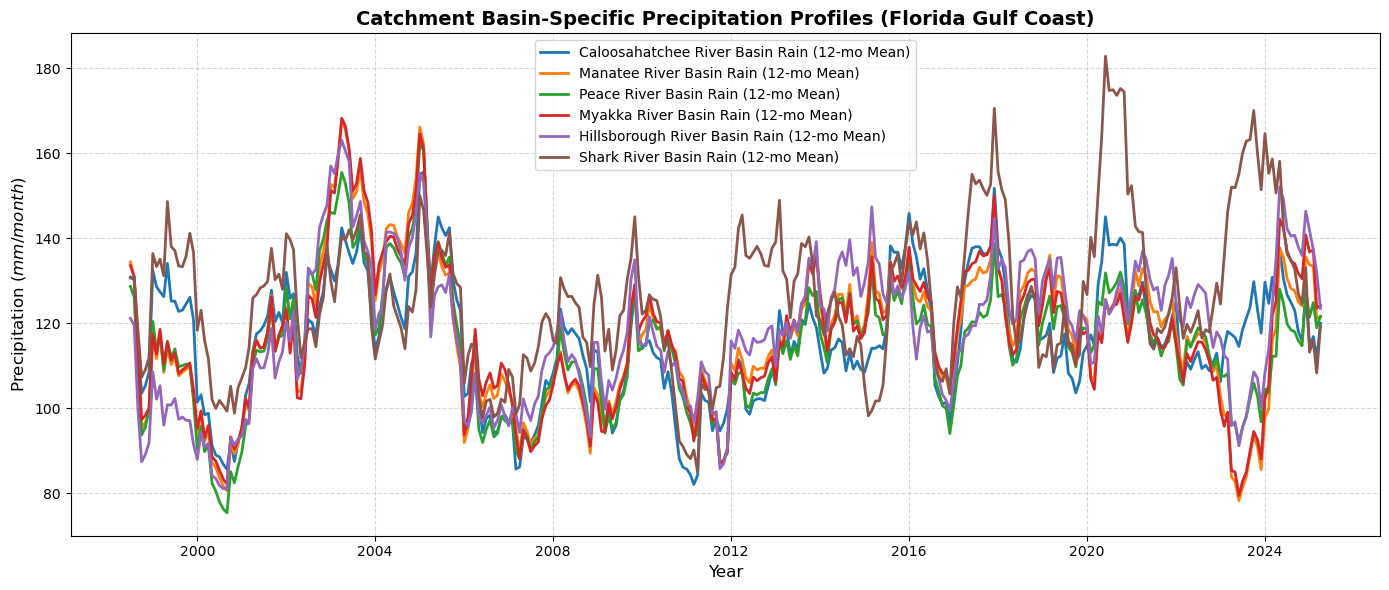

In [6]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import subprocess
import sys
from dataretrieval import nldi
import rioxarray
import shapely.geometry


# 1. Define target river names and their corresponding USGS gage IDs
river_stations = {
    "Caloosahatchee River": "USGS-02292900",
    "Manatee River": "USGS-02299950",
    "Peace River": "USGS-02296750",
    "Myakka River": "USGS-02298830",
    "Hillsborough River": "USGS-02304500",
    "Shark River": "USGS-252230081021300"
}

# 2. Programmatically fetch the Catchment Basin boundaries using USGS NLDI
basin_polygons = {}
print("📡 Fetching catchment polygons from USGS NLDI API...")

for name, site_id in river_stations.items():
    try:
        # Fetch the watershed boundary polygon for the given gage
        # feature_source='nwissite' maps directly to the USGS gage identifier
        basin_gdf = nldi.get_basin(feature_source='nwissite', feature_id=site_id)
        
        if not basin_gdf.empty:
            # Store the geometry (ensuring WGS84 projection to match GPM IMERG)
            basin_polygons[name] = basin_gdf.to_crs(epsg=4326).geometry.iloc[0]
            print(f"✅ Retrieved polygon for {name} (Area: {basin_gdf.to_crs(epsg=5070).area.iloc[0]/1e6:.1f} km²)")
    except Exception as e:
        print(f"❌ Failed to get boundary for {name}: {e}")

# 3. Calculate Mean Monthly Precipitation inside each Basin Polygon
# Note: This assumes 'ds' from your GPM IMERG step is loaded in memory
if 'ds' in locals() and basin_polygons:
    print("\n🌧️ Slicing precipitation data inside catchment boundaries...")
    
    # Ensure the xarray dataset has a properly defined coordinate reference system (CRS)
    if ds.rio.crs is None:
        ds = ds.rio.write_crs("EPSG:4326")
        
    basin_precipitation_time_series = {}

    for name, poly in basin_polygons.items():
        # Clip the 3D precipitation dataset using the river's basin polygon boundary
        clipped_ds = ds['precipitation'].rio.clip([poly], ds.rio.crs, drop=True)
        
        # Average spatially across the lat/lon grid cells inside the polygon boundary
        lat_name = 'latitude' if 'latitude' in clipped_ds.coords else 'lat'
        lon_name = 'longitude' if 'longitude' in clipped_ds.coords else 'lon'
        
        basin_mean = clipped_ds.mean(dim=[lat_name, lon_name], skipna=True)
        basin_precipitation_time_series[name] = pd.Series(basin_mean.values, index=pd.to_datetime(basin_mean.time.values))
        print(f"📊 Extracted precipitation time series for {name}")

    # 4. Plot the comparison of catchment basin rainfall
    plt.figure(figsize=(14, 6))
    for name, series in basin_precipitation_time_series.items():
        # 12-month rolling mean helps smooth seasonal changes for clearer structural trend comparisons
        plt.plot(series.index, series.rolling(12, center=True).mean(), label=f"{name} Basin Rain (12-mo Mean)", linewidth=2)
        
    plt.title("Catchment Basin-Specific Precipitation Profiles (Florida Gulf Coast)", fontsize=14, fontweight='bold')
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Precipitation ($mm/month$)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("\n⚠️ 'ds' dataset not found or no polygons retrieved. Check your cells above.")

### Map Catchment Basin Polygons

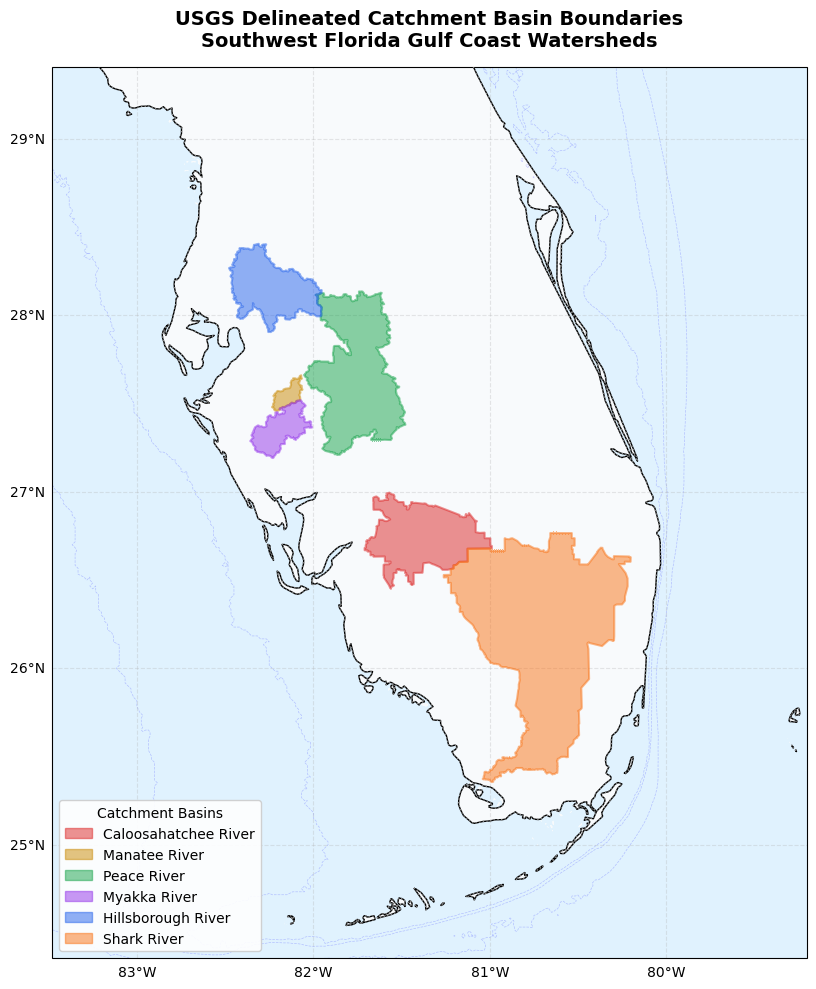

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import Polygon

# Color mapping for each river curve
river_colors = {
    "Caloosahatchee River": "#dc2626",  # Red
    "Manatee River": "#ca8a04",         # Gold
    "Peace River": "#16a34a",           # Green
    "Myakka River": "#9333ea",           # Purple
    "Hillsborough River": "#2563eb",      # Blue
    "Shark River": "#f97316"              # Orange
}

# --- 1. PREPARE THE GEOPANDAS DATAFRAME ---
# Ensure basin_polygons dictionary from previous steps is loaded
if 'basin_polygons' in locals() and basin_polygons:
    
    # Convert our dictionary of Shapely geometries into a GeoDataFrame
    gdf_data = []
    for name, poly in basin_polygons.items():
        gdf_data.append({
            'river_name': name,
            'geometry': poly,
            'color': river_colors.get(name, 'gray') # Pull from your river_colors dict
        })
        
    basins_gdf = gpd.GeoDataFrame(gdf_data, crs="EPSG:4326")

    # --- 2. SETUP THE MAP PROJECTION ---
    fig = plt.figure(figsize=(12, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Dynamically adjust map limits to focus tightly around our basins
    # [minx, miny, maxx, maxy]
    bounds = basins_gdf.total_bounds
    padding = 1
    ax.set_extent([bounds[0] - padding, bounds[2] + padding, 
                   bounds[1] - padding, bounds[3] + padding], 
                  crs=ccrs.PlateCarree())

    # --- 3. ADD BASEMAP FEATURES ---
    ax.add_feature(cfeature.OCEAN, facecolor='#e0f2fe', zorder=1)
    ax.add_feature(cfeature.LAND, facecolor='#f8fafc', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black', zorder=3)
    ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='gray', zorder=3)
    
    # Optional: Add ETOPO bathymetry contours if topo_ds is available in memory
    if 'topo_ds' in locals() and topo_ds is not None:
        ax.contour(topo_ds.longitude, topo_ds.latitude, topo_ds.altitude, 
                   levels=[-200, -50, -20], colors='blue', linewidths=0.5, 
                   alpha=0.2, transform=ccrs.PlateCarree(), zorder=2)

    # --- 4. PLOT CATCHMENT POLYGONS WITH CORRESPONDING COLORS ---
    for _, row in basins_gdf.iterrows():
        # Plot each polygon individually to apply its unique color mapping
        ax.add_geometries([row['geometry']], crs=ccrs.PlateCarree(),
                          facecolor=row['color'], alpha=0.5, 
                          edgecolor=row['color'], linewidth=1.5,
                          label=row['river_name'], zorder=4)

    # --- 5. FORMATTING & LABELS ---
    # Draw gridlines
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3, zorder=5)
    gl.top_labels = False
    gl.right_labels = False

    # Create a custom legend matching the polygon face colors
    import matplotlib.patches as mpatches
    legend_handles = [
        mpatches.Patch(color=row['color'], alpha=0.5, ec=row['color'], label=row['river_name'])
        for _, row in basins_gdf.iterrows()
    ]
    ax.legend(handles=legend_handles, loc='lower left', title="Catchment Basins", 
              frameon=True, facecolor='white', framealpha=0.9, fontsize=10)

    plt.title("USGS Delineated Catchment Basin Boundaries\nSouthwest Florida Gulf Coast Watersheds", 
              fontsize=14, fontweight='bold', pad=15)
    
    plt.tight_layout()
    plt.show()

else:
    print("❌ Error: 'basin_polygons' dictionary not found. Ensure the USGS NLDI step ran successfully.")

### Unified River Discharge vs. Land Precipitation Time Series

📡 Fetching River Discharge records from USGS API...
✅ Successfully loaded 336 months for Shark River


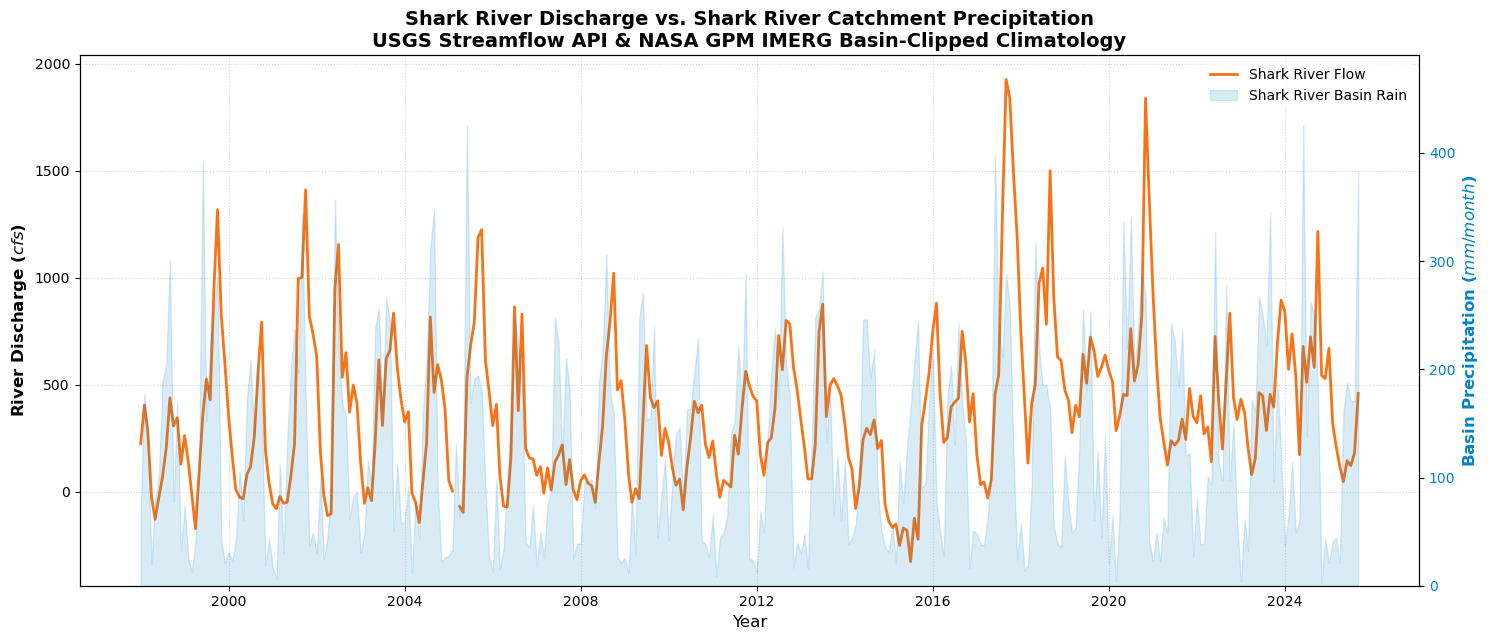

In [11]:
import io
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. DEFINE API PARAMETERS & SELECTION ---
river_stations = {
    "Caloosahatchee River": "02292900",
    "Manatee River": "02299950",
    "Peace River": "02296750",
    "Myakka River": "02298830",
    "Hillsborough River": "02304500",
    "Shark River": "252230081021300"
}

# -------------------------------------------------------------------------
# CHANGE THIS VARIABLE to select which river you want to plot.
# Options: "Caloosahatchee River", "Manatee River", "Peace River", "Myakka River"
# Set to None if you want to fall back to plotting all curves together.
# -------------------------------------------------------------------------
selected_river = "Shark River" 

start_date = "1998-01-01"
end_date = "2025-12-31"

# --- 2. FETCH DISCHARGE DATA VIA THE USGS NWIS API ---
discharge_series = {}

print("📡 Fetching River Discharge records from USGS API...")
# Determine which rivers to loop over based on selection
target_rivers = [selected_river] if selected_river in river_stations else list(river_stations.keys())

for name in target_rivers:
    station_id = river_stations[name]
    # Shark River is tidal; use tidally-filtered discharge (72137). Others use standard (00060).
    param_code = "72137" if name == "Shark River" else "00060"

    api_url = (
    f"https://waterservices.usgs.gov/nwis/dv/"
    f"?format=rdb&sites={station_id}&startDT={start_date}&endDT={end_date}&parameterCd={param_code}"
)

    try:
        response = requests.get(api_url, timeout=60)
        response.raise_for_status()

        # Parse RDB text format (skipping comment metadata starting with '#')
        data_lines = [line for line in response.text.split("\n") if not line.startswith("#")]
        rdb_data = "\n".join(data_lines)

        df = pd.read_csv(io.StringIO(rdb_data), sep="\t")
        df = df.drop(index=0).reset_index(drop=True)

        df["datetime"] = pd.to_datetime(df["datetime"])
        flow_col = [c for c in df.columns if param_code in c and not c.endswith("_cd")][0]

        df["discharge_cfs"] = pd.to_numeric(df[flow_col], errors="coerce")
        df = df.set_index("datetime")
        
        # Resample to monthly mean to align with monthly GPM IMERG data
        monthly_df = df["discharge_cfs"].resample("MS").mean()
        discharge_series[name] = monthly_df
        print(f"✅ Successfully loaded {len(monthly_df)} months for {name}")

    except Exception as e:
        print(f"❌ Failed to fetch data for {name}. Error: {e}")

# --- 3. UNIFIED TIME SERIES VISUALIZATION (USING BASIN-SPECIFIC PRECIPITATION) ---
# Ensure that the basin-specific precipitation dictionary from your previous cell is loaded
if "basin_precipitation_time_series" in locals():
    
    # Determine which precipitation data to plot
    if selected_river in basin_precipitation_time_series:
        # Use the specific catchment series for the selected river
        precip_df = basin_precipitation_time_series[selected_river]
        precip_label = f"{selected_river} Basin Rain"
    else:
        # Fallback: if multiple rivers are plotted, we can average them or default to the first available basin
        first_basin = list(basin_precipitation_time_series.keys())[0]
        precip_df = basin_precipitation_time_series[first_basin]
        precip_label = f"{first_basin} Basin Rain (Default)"
        print(f"⚠️ Note: Multiple rivers selected. Using {first_basin} catchment precipitation for background.")

    # Define plot layout
    fig, ax1 = plt.subplots(figsize=(15, 6.5))
    
    # ------------------ RIGHT Y-AXIS: CATCHMENT PRECIPITATION (BACKGROUND) ------------------
    ax2 = ax1.twinx()
    common_timeline = precip_df.index
    
    # Render basin-specific precipitation as a semi-transparent background fill
    precip_fill = ax2.fill_between(
        common_timeline,
        0,
        precip_df,
        color="#0284c7",
        alpha=0.15,
        label=precip_label
    )
    
    ax2.set_ylabel("Basin Precipitation ($mm/month$)", color="#0284c7", fontsize=12, fontweight="bold")
    ax2.tick_params(axis="y", labelcolor="#0284c7")
    ax2.set_ylim(0, float(precip_df.max()) * 1.15)  # Add 15% headroom above precipitation peaks
    
    # ------------------ LEFT Y-AXIS: SELECTED RIVER DISCHARGE ------------------
    discharge_handles = []
    for name, discharge in discharge_series.items():
        overlap_idx = discharge.index.intersection(common_timeline)
        
        line, = ax1.plot(
            overlap_idx,
            discharge.loc[overlap_idx],
            color=river_colors.get(name, "black"),
            linewidth=2.0,
            label=f"{name} Flow",
            zorder=3  # Pushes line in front of the precipitation fill
        )
        discharge_handles.append(line)
        
    ax1.set_ylabel("River Discharge ($cfs$)", color="black", fontsize=12, fontweight="bold")
    ax1.tick_params(axis="y", labelcolor="black")
    
    # Scale adjustment based on selection
    if selected_river in river_stations:
        ax1.set_yscale('linear')
        title_river_text = selected_river
        title_precip_text = f"{selected_river} Catchment"
    else:
        ax1.set_yscale('log')
        title_river_text = "Florida Gulf Coast Rivers"
        title_precip_text = "Catchment-Specific"
        
    ax1.set_xlabel("Year", fontsize=12)
    ax1.grid(True, which="both", linestyle=":", alpha=0.5, zorder=1)
    
    # ------------------ LEGENDS & FORMATTING ------------------
    all_handles = discharge_handles + [precip_fill]
    all_labels = [h.get_label() for h in all_handles]
    ax1.legend(all_handles, all_labels, loc="upper right", frameon=True, facecolor="white", edgecolor="none")
    
    plt.title(
        f"{title_river_text} Discharge vs. {title_precip_text} Precipitation\n"
        f"USGS Streamflow API & NASA GPM IMERG Basin-Clipped Climatology", 
        fontsize=14, 
        fontweight="bold"
    )
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("❌ Error: 'basin_precipitation_time_series' dict must be generated in the previous cell to run this plot.")

### Seasonal Cumulative River Discharge Analysis

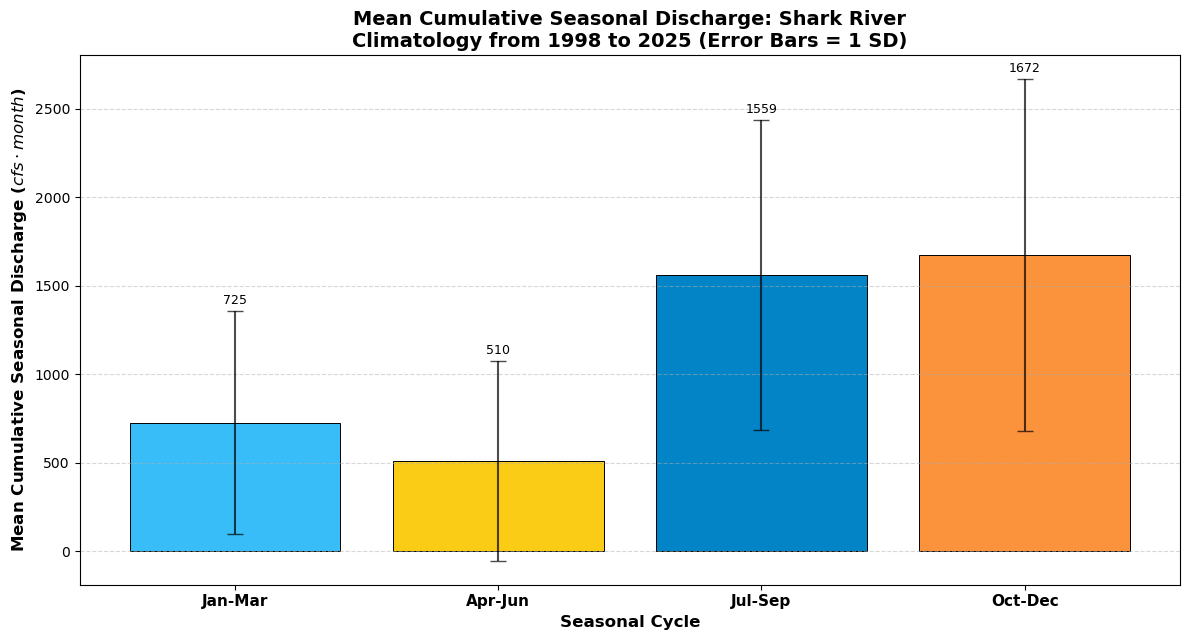

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. DEFINE SEASONAL CYCLES ---
# Define the 3-month blocks
seasons = {
    "Jan-Mar": [1, 2, 3],
    "Apr-Jun": [4, 5, 6],
    "Jul-Sep": [7, 8, 9],
    "Oct-Dec": [10, 11, 12]
}

# Define colors for each season to make the bar chart visually distinct
season_colors = {
    "Jan-Mar": "#38bdf8",  # Light Blue
    "Apr-Jun": "#facc15",  # Yellow
    "Jul-Sep": "#0284c7",  # Darker Blue
    "Oct-Dec": "#fb923c"   # Orange
}

# --- 2. CALCULATE SEASONAL CUMULATIVE DISCHARGE ---
if "discharge_series" in locals() and discharge_series:
    # Set up the plot layout
    # If a single river is selected, we show a clean single bar plot. 
    # If multiple are active, we show a grouped bar chart.
    num_rivers = len(discharge_series)
    fig, ax = plt.subplots(figsize=(12, 6.5))
    
    # We will collect seasonal stats for each river
    x_coords = np.arange(len(seasons))  # [0, 1, 2, 3] for the seasons
    bar_width = 0.8 / num_rivers        # Automatically scale bar widths based on active rivers
    
    for i, (name, series) in enumerate(discharge_series.items()):
        # Convert Series to DataFrame to easily work with years and months
        df_flow = series.to_frame(name="discharge")
        df_flow["year"] = df_flow.index.year
        df_flow["month"] = df_flow.index.month
        
        # Calculate cumulative seasonal discharge per year
        seasonal_records = {season_name: [] for season_name in seasons}
        
        # Group by year and sum the monthly flows for each defined season
        for year, group in df_flow.groupby("year"):
            # Ensure we only calculate cumulative values for years with a complete season record (3 months)
            for season_name, months in seasons.items():
                season_data = group[group["month"].isin(months)]
                if len(season_data) == 3:
                    # Cumulative flow proxy: sum of monthly means (cfs-months)
                    # To convert to true volume, we could multiply by seconds in a month, 
                    # but summing the cfs is the standard hydrological relative index.
                    cumulative_flow = season_data["discharge"].sum()
                    seasonal_records[season_name].append(cumulative_flow)
        
        # Calculate the climatological Mean and Standard Deviation for each season
        means = [np.mean(seasonal_records[s]) if seasonal_records[s] else 0 for s in seasons]
        stds = [np.std(seasonal_records[s]) if seasonal_records[s] else 0 for s in seasons]
        
        # Position grouped bars side-by-side
        offset = (i - (num_rivers - 1) / 2) * bar_width
        
        # Plot bars
        # If plotting a single river, we color-code by season. If multiple, we color-code by river.
        if num_rivers == 1:
            bars = ax.bar(
                x_coords + offset, 
                means, 
                yerr=stds, 
                width=bar_width, 
                color=[season_colors[s] for s in seasons],
                edgecolor="black", 
                linewidth=0.7, 
                capsize=6, 
                error_kw=dict(ecolor="black", alpha=0.7)
            )
            # Add value labels on top of the bars
            ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=9)
        else:
            # Multi-river plotting colored by river
            bars = ax.bar(
                x_coords + offset, 
                means, 
                yerr=stds, 
                width=bar_width, 
                label=name,
                edgecolor="black", 
                linewidth=0.7, 
                capsize=4,
                error_kw=dict(alpha=0.6)
            )
            ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=8)

    # --- 3. FORMATTING ---
    ax.set_xticks(x_coords)
    ax.set_xticklabels(list(seasons.keys()), fontsize=11, fontweight="bold")
    ax.set_ylabel("Mean Cumulative Seasonal Discharge ($cfs \cdot month$)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Seasonal Cycle", fontsize=12, fontweight="bold")
    
    # Title adjust based on river selection
    if "selected_river" in locals() and selected_river in river_stations:
        plt.title(
            f"Mean Cumulative Seasonal Discharge: {selected_river}\n"
            f"Climatology from {start_date[:4]} to {end_date[:4]} (Error Bars = 1 SD)", 
            fontsize=14, 
            fontweight="bold"
        )
    else:
        plt.title(
            "Mean Cumulative Seasonal Discharge Comparison\n"
            f"Climatology from {start_date[:4]} to {end_date[:4]} (Error Bars = 1 SD)", 
            fontsize=14, 
            fontweight="bold"
        )
        ax.legend(loc="upper right", frameon=True)
        
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

else:
    print("❌ Error: 'discharge_series' must be fetched and loaded in memory before running this seasonal analysis.")

### Climatological Monthly Discharge Cycle with SD Envelope

📡 Fetching complete historical records for ALL rivers from USGS API...
✅ Successfully loaded 336 months for Caloosahatchee River
✅ Successfully loaded 336 months for Manatee River
✅ Successfully loaded 336 months for Peace River
✅ Successfully loaded 336 months for Myakka River
✅ Successfully loaded 336 months for Hillsborough River
✅ Successfully loaded 336 months for Shark River


/tmp/ipykernel_3856919/3798074249.py:145: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left", frameon=True, fontsize=9, facecolor="white", edgecolor="none")


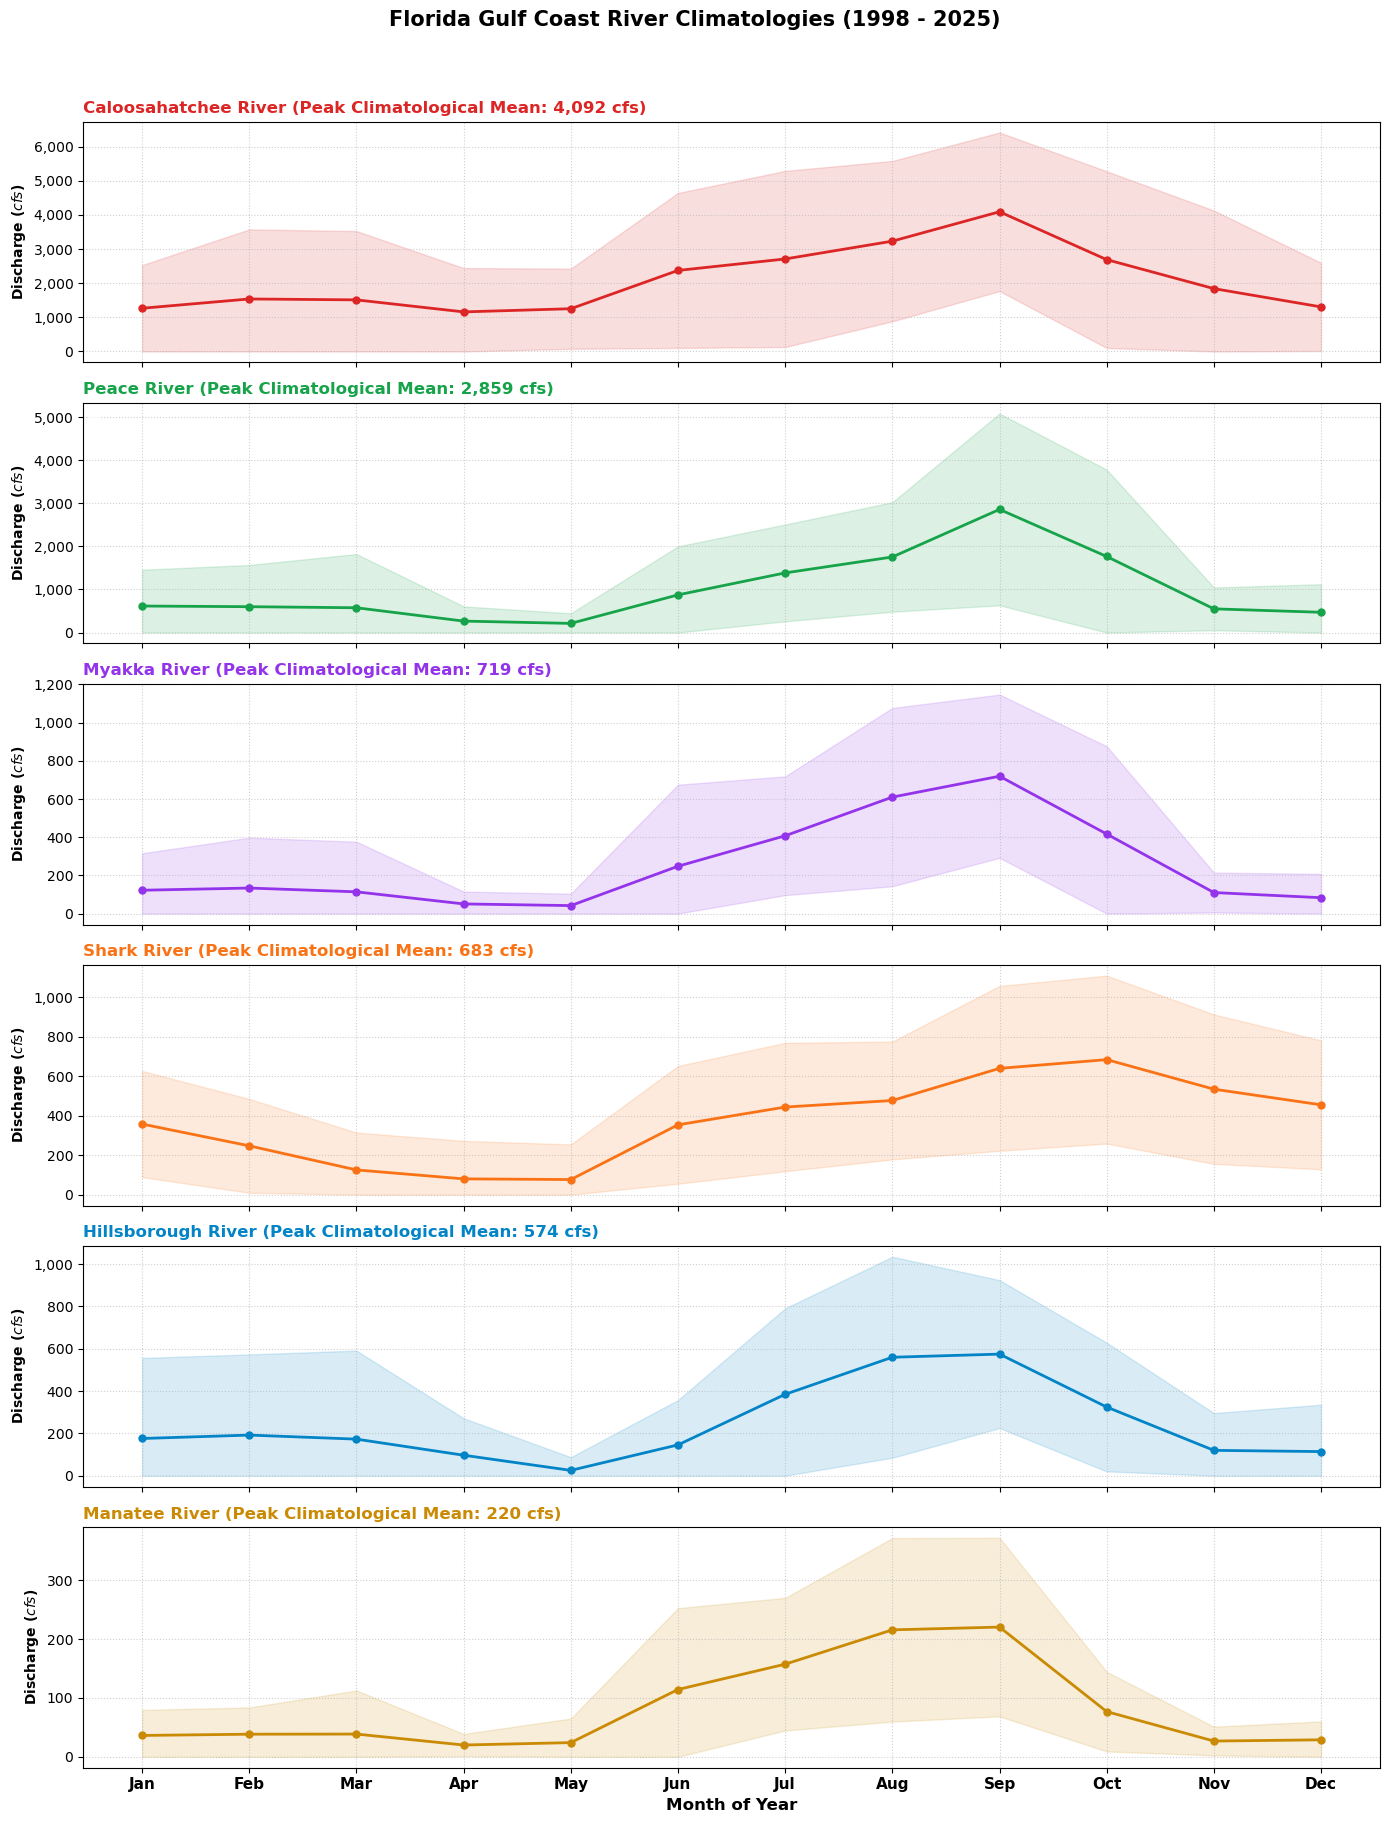

In [17]:
import io
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. DEFINE API PARAMETERS & COLOR PROFILES ---
river_stations = {
    "Caloosahatchee River": "02292900",
    "Manatee River": "02299950",
    "Peace River": "02296750",
    "Myakka River": "02298830",
    "Hillsborough River": "02304500",
    "Shark River": "252230081021300"
}

river_colors = {
    "Caloosahatchee River": "#dc2626",  # Red
    "Manatee River": "#ca8a04",         # Gold
    "Peace River": "#16a34a",           # Green
    "Myakka River": "#9333ea",           # Purple
    "Hillsborough River": "#0284c7",      # Blue
    "Shark River": "#f97316"              # Orange
}

start_date = "1998-01-01"
end_date = "2025-12-31"

# --- 2. FETCH DISCHARGE DATA FOR ALL RIVERS ---
discharge_series = {}

print("📡 Fetching complete historical records for ALL rivers from USGS API...")
for name, station_id in river_stations.items():
    # Shark River is tidal; use tidally-filtered discharge (72137). Others use standard (00060).
    param_code = "72137" if name == "Shark River" else "00060"
    
    api_url = (
        f"https://waterservices.usgs.gov/nwis/dv/"
        f"?format=rdb&sites={station_id}&startDT={start_date}&endDT={end_date}&parameterCd={param_code}"
    )

    try:
        response = requests.get(api_url, timeout=60)
        response.raise_for_status()

        # Parse RDB format (skipping comment metadata starting with '#')
        data_lines = [line for line in response.text.split("\n") if not line.startswith("#")]
        rdb_data = "\n".join(data_lines)

        df = pd.read_csv(io.StringIO(rdb_data), sep="\t")
        df = df.drop(index=0).reset_index(drop=True)

        df["datetime"] = pd.to_datetime(df["datetime"])
        flow_col = [c for c in df.columns if param_code in c and not c.endswith("_cd")][0]

        df["discharge_cfs"] = pd.to_numeric(df[flow_col], errors="coerce")
        df = df.set_index("datetime")
        
        # Resample to monthly mean 
        monthly_df = df["discharge_cfs"].resample("MS").mean()
        discharge_series[name] = monthly_df
        print(f"✅ Successfully loaded {len(monthly_df)} months for {name}")

    except Exception as e:
        print(f"❌ Failed to fetch data for {name}. Error: {e}")

# --- 3. PROCESS, SORT, AND RENDER SUBPLOTS BY PEAK DISCHARGE ---
if discharge_series:
    processed_rivers = []
    global_start_yr = []
    global_end_yr = []

    # Calculate monthly climatological statistics first to find the peak of the mean flow
    for name, series in discharge_series.items():
        river_df = series.to_frame(name="discharge")
        river_df["month"] = river_df.index.month
        
        global_start_yr.append(river_df.index.year.min())
        global_end_yr.append(river_df.index.year.max())
        
        # Calculate monthly climatological statistics
        monthly_stats = river_df.groupby("month")["discharge"].agg(["mean", "std"])
        
        # Identify the peak of the climatological mean flow rate
        peak_mean_flow = monthly_stats["mean"].max()
        
        processed_rivers.append({
            "name": name,
            "monthly_stats": monthly_stats,
            "peak_mean": peak_mean_flow
        })
    
    # Sort the list of rivers descending by their peak mean monthly discharge
    processed_rivers.sort(key=lambda x: x["peak_mean"], reverse=True)

    # Set up a vertical stack of subplots (one for each active river)
    num_rivers = len(processed_rivers)
    fig, axes = plt.subplots(num_rivers, 1, figsize=(14, 3 * num_rivers), sharex=True)
    
    months = np.arange(1, 13)
    month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    for i, data in enumerate(processed_rivers):
        ax = axes[i]
        name = data["name"]
        monthly_stats = data["monthly_stats"]
        peak_mean = data["peak_mean"]
        
        plot_color = river_colors.get(name, "#475569")
        
        # Plot mean annual cycle line
        ax.plot(
            months, 
            monthly_stats["mean"], 
            color=plot_color, 
            linewidth=2.0, 
            marker='o', 
            markersize=5
            # label=f"Mean Monthly Flow"
        )
        
        # Calculate SD limits (clipping lower limit at 0 cfs)
        lower_envelope = np.maximum(monthly_stats["mean"] - monthly_stats["std"], 0)
        upper_envelope = monthly_stats["mean"] + monthly_stats["std"]
        
        # Plot corresponding SD envelope
        ax.fill_between(
            months, 
            lower_envelope, 
            upper_envelope, 
            color=plot_color, 
            alpha=0.15  
            # label="Historical Variance (±1 SD)"
        )
        
        # Subplot Customization
        ax.set_ylabel("Discharge ($cfs$)", fontsize=10, fontweight="bold")
        
        # Append peak flow value to the subplot title to highlight sorting order
        ax.set_title(f"{name} (Peak Climatological Mean: {int(peak_mean):,} cfs)", 
                     fontsize=12, fontweight="bold", color=plot_color, loc="left")
        
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.legend(loc="upper left", frameon=True, fontsize=9, facecolor="white", edgecolor="none")
        
        # Format y-ticks with commas for readability
        ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

    # Set bottom ticks formatting for the shared x-axis
    plt.xticks(months, month_labels, fontsize=11, fontweight="bold")
    plt.xlabel("Month of Year", fontsize=12, fontweight="bold")
    
    # Universal Title
    title_start = min(global_start_yr) if global_start_yr else 1998
    title_end = max(global_end_yr) if global_end_yr else 2025
    
    fig.suptitle(
        f"Florida Gulf Coast River Climatologies ({title_start} - {title_end})\n",
        # f"Ordered by Peak Climatological Discharge (Top to Bottom, Linear Scales)",
        fontsize=15, 
        fontweight="bold",
        y=1.01
    )
    
    plt.tight_layout()
    plt.show()

else:
    print("❌ Error: No data was fetched successfully.")

### Climatological Basin-Specific Precipitation with SD Envelopes

📊 Defined plot order based on Peak Discharge: Caloosahatchee River, Peace River, Myakka River, Shark River, Hillsborough River, Manatee River


/tmp/ipykernel_3856919/815767196.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", frameon=True, fontsize=9, facecolor="white", edgecolor="none")


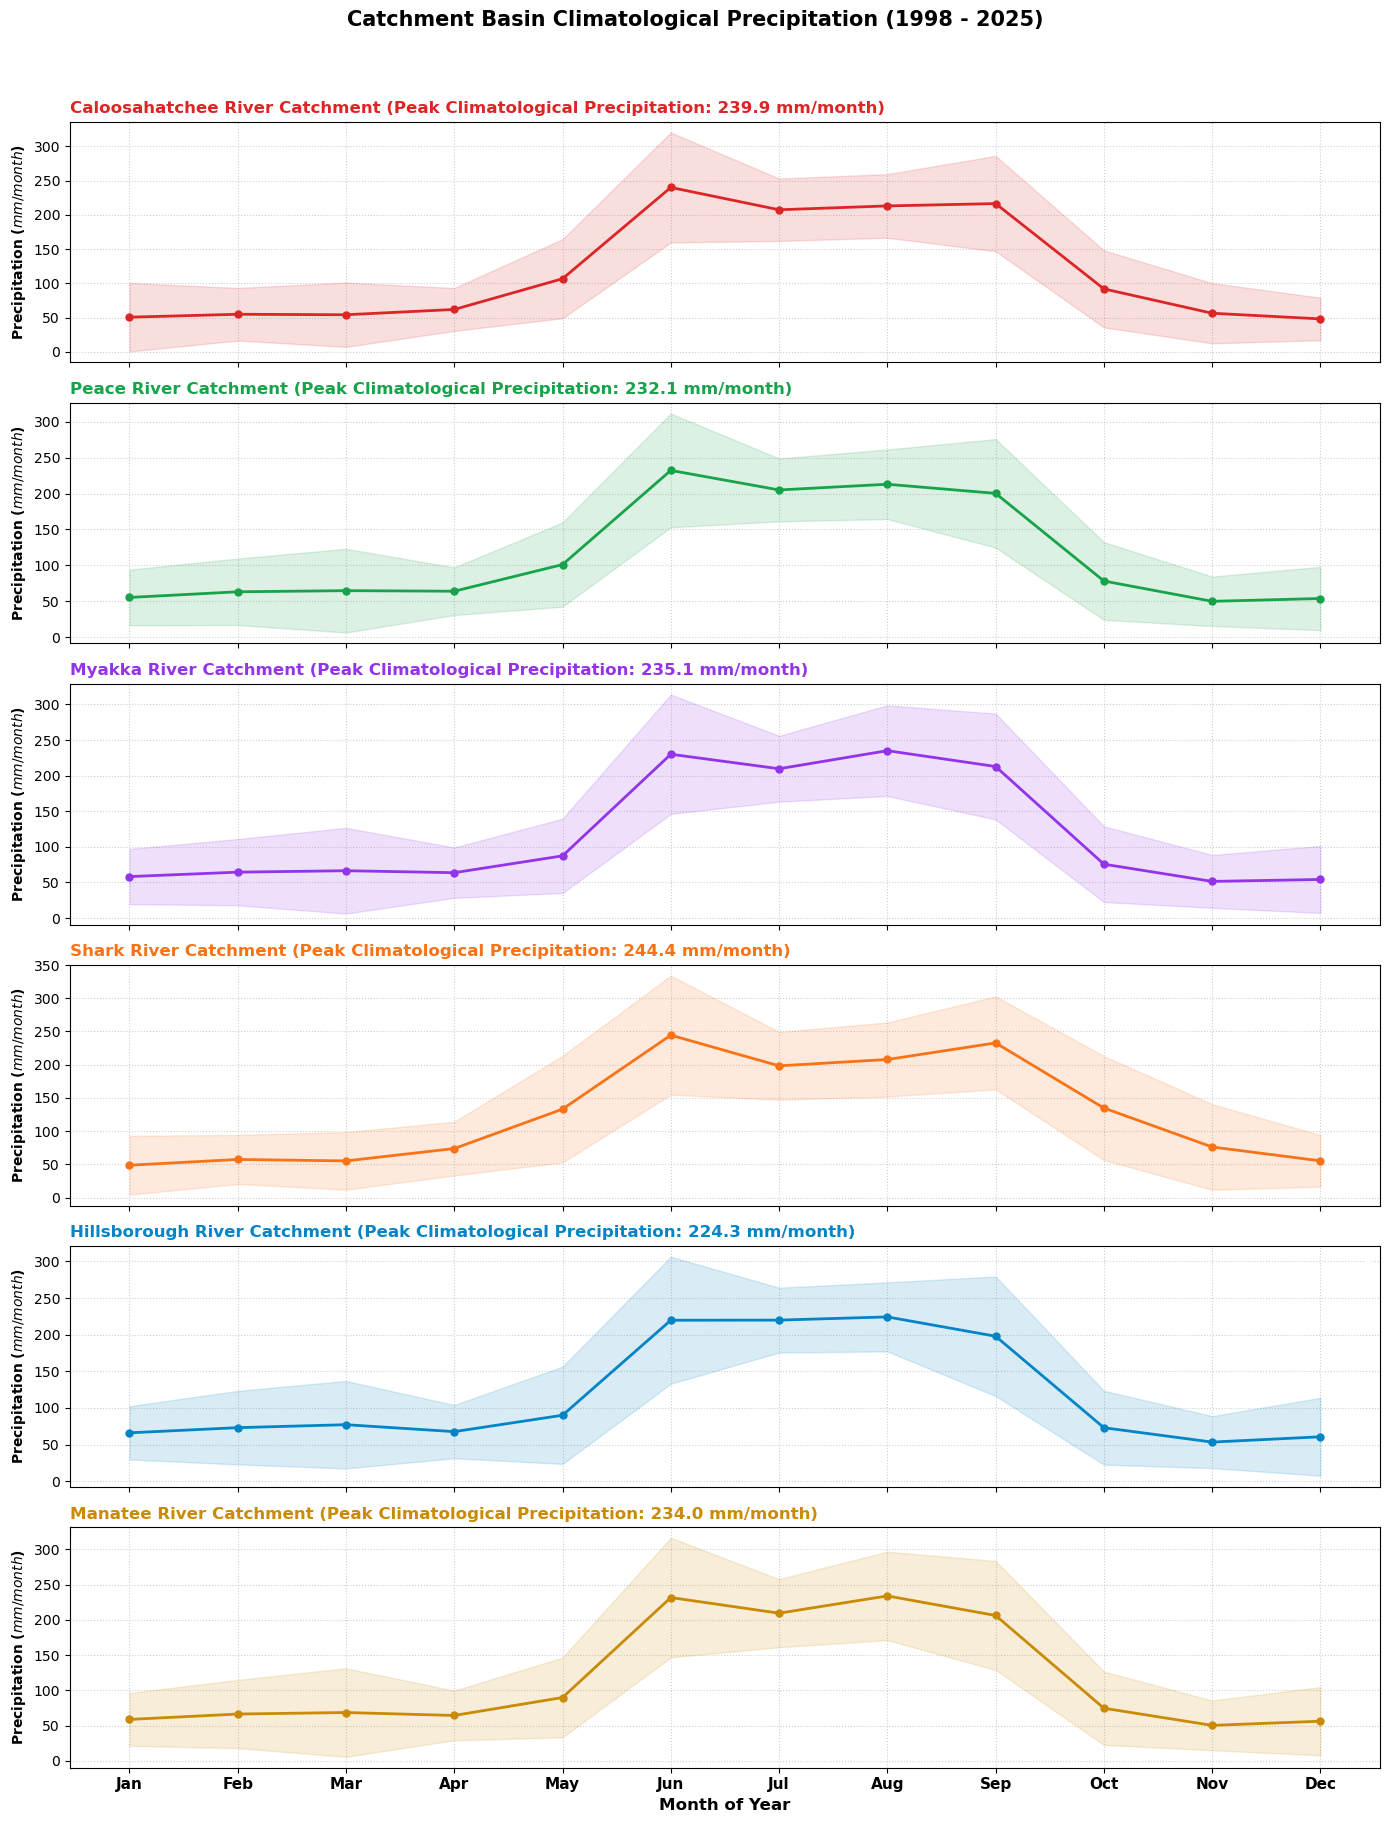

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. VERIFY COLOR & DATA ALIGNMENT ---
if "river_colors" not in locals():
    river_colors = {
        "Caloosahatchee River": "#dc2626",
        "Manatee River": "#ca8a04",
        "Peace River": "#16a34a",
        "Myakka River": "#9333ea",
        "Hillsborough River": "#0284c7",
        "Shark River": "#f97316"  # Orange
    }

# --- 2. DETERMINE THE DISCHARGE-BASED SORTING ORDER ---
sorted_river_names = []

if "discharge_series" in locals() and discharge_series:
    discharge_peaks = {}
    
    # Calculate the peak monthly mean discharge for each river to establish the sorting order
    for name, series in discharge_series.items():
        river_df = series.to_frame(name="discharge")
        river_df["month"] = river_df.index.month
        monthly_mean_discharge = river_df.groupby("month")["discharge"].mean()
        discharge_peaks[name] = monthly_mean_discharge.max()
    
    # Sort the river names descending by their peak discharge
    sorted_river_names = sorted(discharge_peaks, key=discharge_peaks.get, reverse=True)
    print(f"📊 Defined plot order based on Peak Discharge: {', '.join(sorted_river_names)}")
else:
    # Hydrological fallback order if discharge_series is missing from memory:
    # (Caloosahatchee > Peace > Hillsborough > Myakka > Manatee)
    fallback_order = ["Caloosahatchee River", "Peace River", "Hillsborough River", "Myakka River", "Manatee River"]
    sorted_river_names = [r for r in fallback_order if r in basin_precipitation_time_series]
    print("⚠️ 'discharge_series' not found in memory. Using default climatological discharge order.")

# --- 3. PROCESS PRECIPITATION DATA USING THE DISCHARGE ORDER ---
if "basin_precipitation_time_series" in locals() and basin_precipitation_time_series:
    processed_basins = []
    global_start_yr = []
    global_end_yr = []

    # Map our precipitation data to the established discharge-sorted list
    for name in sorted_river_names:
        if name in basin_precipitation_time_series:
            series = basin_precipitation_time_series[name]
            
            # Convert precipitation time series to a structured DataFrame
            precip_df = series.to_frame(name="precipitation")
            precip_df["month"] = precip_df.index.month
            
            # Track active years for title accuracy
            global_start_yr.append(precip_df.index.year.min())
            global_end_yr.append(precip_df.index.year.max())
            
            # Calculate monthly climatological stats (mean and standard deviation)
            monthly_stats = precip_df.groupby("month")["precipitation"].agg(["mean", "std"])
            
            # Keep track of the peak mean precipitation value for labels
            peak_mean_precip = monthly_stats["mean"].max()
            
            processed_basins.append({
                "name": name,
                "monthly_stats": monthly_stats,
                "peak_mean": peak_mean_precip
            })

    # --- 4. RENDER SUBPLOTS ---
    num_basins = len(processed_basins)
    fig, axes = plt.subplots(num_basins, 1, figsize=(14, 3 * num_basins), sharex=True)
    
    if num_basins == 1:
        axes = [axes]
        
    months = np.arange(1, 13)
    month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    for i, data in enumerate(processed_basins):
        ax = axes[i]
        name = data["name"]
        monthly_stats = data["monthly_stats"]
        peak_mean = data["peak_mean"]
        
        plot_color = river_colors.get(name, "#475569")
        
        # Plot mean annual precipitation cycle line
        ax.plot(
            months, 
            monthly_stats["mean"], 
            color=plot_color, 
            linewidth=2.0, 
            marker='o', 
            markersize=5,
            # label="Mean Monthly Precipitation",
            zorder=3
        )
        
        # Calculate standard deviation envelope bounds (clipping lower bound at 0 mm/month)
        lower_envelope = np.maximum(monthly_stats["mean"] - monthly_stats["std"], 0)
        upper_envelope = monthly_stats["mean"] + monthly_stats["std"]
        
        # Plot standard deviation envelope
        ax.fill_between(
            months, 
            lower_envelope, 
            upper_envelope, 
            color=plot_color, 
            alpha=0.15,  
            # label="Historical Variance (±1 SD)",
            zorder=2
        )
        
        # Subplot Customization
        ax.set_ylabel("Precipitation ($mm/month$)", fontsize=10, fontweight="bold")
        
        # Title denotes catchment name alongside its peak precipitation month value
        ax.set_title(f"{name} Catchment (Peak Climatological Precipitation: {peak_mean:.1f} mm/month)", 
                     fontsize=12, fontweight="bold", color=plot_color, loc="left")
        
        ax.grid(True, linestyle=":", alpha=0.6, zorder=1)
        ax.legend(loc="upper right", frameon=True, fontsize=9, facecolor="white", edgecolor="none")

    # Set bottom ticks formatting for the shared x-axis
    plt.xticks(months, month_labels, fontsize=11, fontweight="bold")
    plt.xlabel("Month of Year", fontsize=12, fontweight="bold")
    
    # Universal Title
    title_start = min(global_start_yr) if global_start_yr else "N/A"
    title_end = max(global_end_yr) if global_end_yr else "N/A"
    
    fig.suptitle(
        f"Catchment Basin Climatological Precipitation ({title_start} - {title_end})\n",
        # f"Ordered by Peak Monthly River Discharge (Top to Bottom, Linear Scales)", 
        fontsize=15, 
        fontweight="bold",
        y=1.01
    )
    
    plt.tight_layout()
    plt.show()

else:
    print("❌ Error: 'basin_precipitation_time_series' dictionary not found. Run your upstream spatial clipping cell first!")